# **Proyek Pertama Machine Learning Terapan: Predictive Analytics**
- **Nama:** Dimas Sukmana
- **Email:** sukmanadimas4@gmail.com
- **ID Dicoding:** MC299D5Y1765

# **Import Library**

Langkah pertama dalam proses analisis prediktif ini adalah mengimpor sejumlah library yang dibutuhkan. Library ini mencakup fungsi-fungsi esensial untuk manipulasi data, visualisasi, serta pembangunan dan evaluasi model.

- `numpy` dan `pandas` digunakan untuk pemrosesan data numerik dan tabular.
- `matplotlib.pyplot` dan `seaborn` digunakan untuk membuat visualisasi data eksploratif.
- Modul dari `scikit-learn (sklearn)` digunakan untuk preprocessing, pembentukan model regresi, dan evaluasi performa model.

Mengimpor seluruh library di awal memastikan bahwa semua dependensi tersedia sebelum proses analisis dimulai.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib: memastikan plot Matplotlib ditampilkan langsung di output sel notebook
import seaborn as sns

In [2]:
# Mengimpor PCA dari scikit-learn.decomposition untuk mereduksi dimensi fitur
from sklearn.decomposition import PCA

# Mengimpor fungsi train_test_split dari scikit-learn.model_selection untuk melakukan splitting dataset
from sklearn.model_selection import train_test_split

# Mengimpor StandardScaler dari scikit-learn.preprocessing untuk melakukan normalisasi skala data
from sklearn.preprocessing import StandardScaler

# Mengimpor KNeighborsResgressor, RandomForestRegressor, dan AdaBoostRegressor untuk membuat model regresi
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.svm import SVR

# Mengimpor fungsi mean_squared_error dari scikit-learn.metrics sebagai metrik evaluasi model regresi
from sklearn.metrics import mean_squared_error

# **Data Loading**

Dataset yang digunakan dalam proyek ini adalah **[California Housing Prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices)**, yang bersumber dari platform Kaggle. Dataset ini berisi informasi mengenai karakteristik wilayah perumahan di negara bagian California, seperti jumlah kamar, populasi, dan pendapatan median, serta harga median rumah sebagai variabel target.

Pada tahap ini, dataset dimuat ke dalam struktur data `DataFrame` menggunakan fungsi `read_csv()` dari pustaka `pandas`. Kemudian, ditampilkan beberapa baris pertama dari data untuk memperoleh gambaran umum terkait struktur dan tipe variabel yang tersedia.


In [3]:
# Mengimpor library kagglehub untuk memudahkan pengunduhan dataset dari Kaggle
import kagglehub

path = kagglehub.dataset_download('camnugent/california-housing-prices') # Mengunduh dataset 'California Housing Prices' dari Kaggle menggunakan kagglehub
file_path = path + '/housing.csv' # Membuat path lengkap ke file 'housing.csv' di dalam folder dataset yang diunduh
df = pd.read_csv(file_path) # Memuat data dari file CSV yang diunduh
df.head() # Menampilkan lima baris pertama DataFrame

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# **Exploratory Data Analysis**

Exploratory Data Analysis (EDA) merupakan tahap penting dalam analisis data yang bertujuan untuk memahami karakteristik dasar dari dataset, mendeteksi pola atau anomali, serta mengevaluasi distribusi dan hubungan antar variabel.

Pada tahap ini dilakukan beberapa langkah berikut:

1. **Menampilkan informasi umum mengenai dataset**  
   - Jumlah baris dan kolom
   - Tipe data setiap fitur
   - Jumlah nilai yang hilang (missing values)

2. **Analisis statistik deskriptif**  
   Disediakan ringkasan statistik seperti nilai minimum, maksimum, kuartil, dan nilai rata-rata untuk masing-masing fitur numerik guna memahami skala dan penyebaran data.

3. **Univariate Analysis**  
   Dilakukan untuk mengevaluasi distribusi masing-masing variabel secara individu. Visualisasi yang digunakan antara lain:
    - **Histogram dan plot distribusi**: digunakan untuk mengamati bentuk distribusi dari variabel kategorikal `ocean_proximity` dan variabel numerik seperti `longitude`, `latitude`, `housing_median_age`, `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`, dan `median_house_value`.
  
4. **Multivariate Analysis**  
   Bertujuan untuk memahami hubungan antar variabel, terutama antara variabel prediktor dan variabel target (`median_house_value`).
  Beberapa langkah analisis yang dilakukan meliputi:
    - **Pairplot**: memberikan gambaran hubungan antar beberapa fitur sekaligus, serta distribusi masing-masing fitur.
    - **Heatmap korelasi**: digunakan untuk mengukur kekuatan hubungan linier antar variabel numerik.

Hasil EDA ini akan menjadi dasar untuk proses **feature engineering** dan pemilihan variabel pada tahap pemodelan selanjutnya.

## **Data Information**

In [4]:
# Menampilkan informasi umum mengenai dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Dataset `California Housing Prices` memiliki 20640 baris dan 10 kolom. Sebagian besar kolom memiliki tipe data float64, yang menunjukkan data numerik. Kolom `ocean_proximity` memiliki tipe data object, yang merupakan data kategorikal. Terlihat ada nilai yang hilang (Non-Null Count kurang dari 20640) pada kolom total_bedrooms.

In [5]:
# Menampilkan informasi jumlah nilai yang hilang (missing values)
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


Berdasarkan hasil pengecekan, kolom `total_bedrooms` teridentifikasi memiliki 207 nilai yang hilang. Jumlah ini relatif kecil dibandingkan dengan total ukuran dataset, penanganan missing values ini akan dilakukan pada tahap data preprocessing melalui penghapusan baris yang teridentifikasi.

## **Variable Description**

In [6]:
# Melakukan analisis statistik deskriptif
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


- Sebaran data: Kolom seperti `total_rooms`, `total_bedrooms`, `population`, dan `households` memiliki nilai maksimum yang jauh lebih besar dari nilai kuartil ketiga (75%), menunjukkan kemungkinan adanya outlier atau distribusi yang sangat miring ke kanan (right-skewed).
- Usia rata-rata rumah: Usia median rumah (`housing_median_age`) adalah sekitar 29 tahun, dengan beberapa rumah berusia hingga 52 tahun.
- Pendapatan: Pendapatan median (`median_income`) berkisar antara 0.5 hingga sekitar 15, dengan rata-rata sekitar 3.87.
- Harga rumah: Harga median rumah (`median_house_value`) memiliki rentang yang luas, dari 14999 hingga 500001.
- Variasi: `median_house_value` menunjukkan variasi yang cukup besar (std = 115395.6), menandakan perbedaan harga yang signifikan di berbagai lokasi. `total_bedrooms` juga memiliki standar deviasi yang relatif tinggi, yang mungkin terkait dengan keberadaan nilai yang hilang atau outlier yang teridentifikasi sebelumnya.

## **Univariate Analysis**

In [7]:
# Melakukan pemisahan feature untuk mempermudah dalam melakukan Univariate Analysis
numerical_features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
categorical_features = ['ocean_proximity']

#### **Categorical Features**

**Feature ocean_proximity**

                 Jumlah Sampel  Presentase
ocean_proximity                           
<1H OCEAN                 9136        44.3
INLAND                    6551        31.7
NEAR OCEAN                2658        12.9
NEAR BAY                  2290        11.1
ISLAND                       5         0.0


<Axes: title={'center': 'ocean_proximity'}, xlabel='ocean_proximity'>

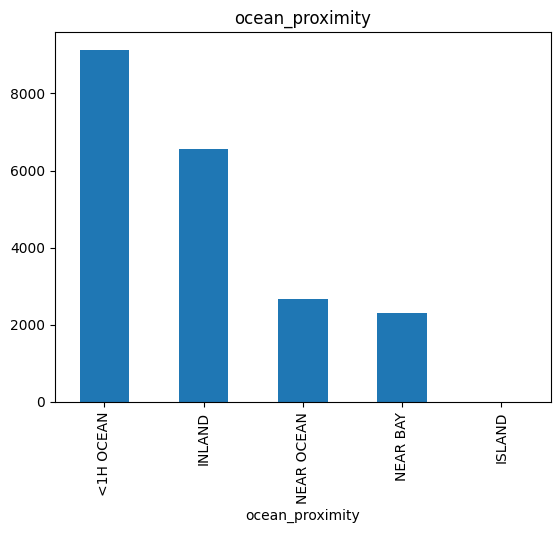

In [8]:
feature = categorical_features[0] # Mengambil nama fitur kategorikal dengan index pertama

# Menghitung jumlah dan persentase kemunculan setiap kategori pada fitur yang dipilih
count = df[feature].value_counts()
percent = 100*df[feature].value_counts(normalize=True)

# Membuat DataFrame baru untuk menampilkan hasil hitungan jumlah dan persentase
DF = pd.DataFrame({'Jumlah Sampel':count, 'Presentase':percent.round(1)})
print(DF)

# Membuat visualisasi (diagram batang) dari jumlah kemunculan setiap kategori
count.plot(kind='bar', title=feature)

Univariate Analysis pada fitur kategorikal `ocean_proximity` menunjukkan dominasi properti dekat laut (`<1H OCEAN`). Kategori `ISLAND` sangat jarang, mengindikasikan distribusi yang sangat tidak seimbang dalam dataset.

#### **Numerical Features**

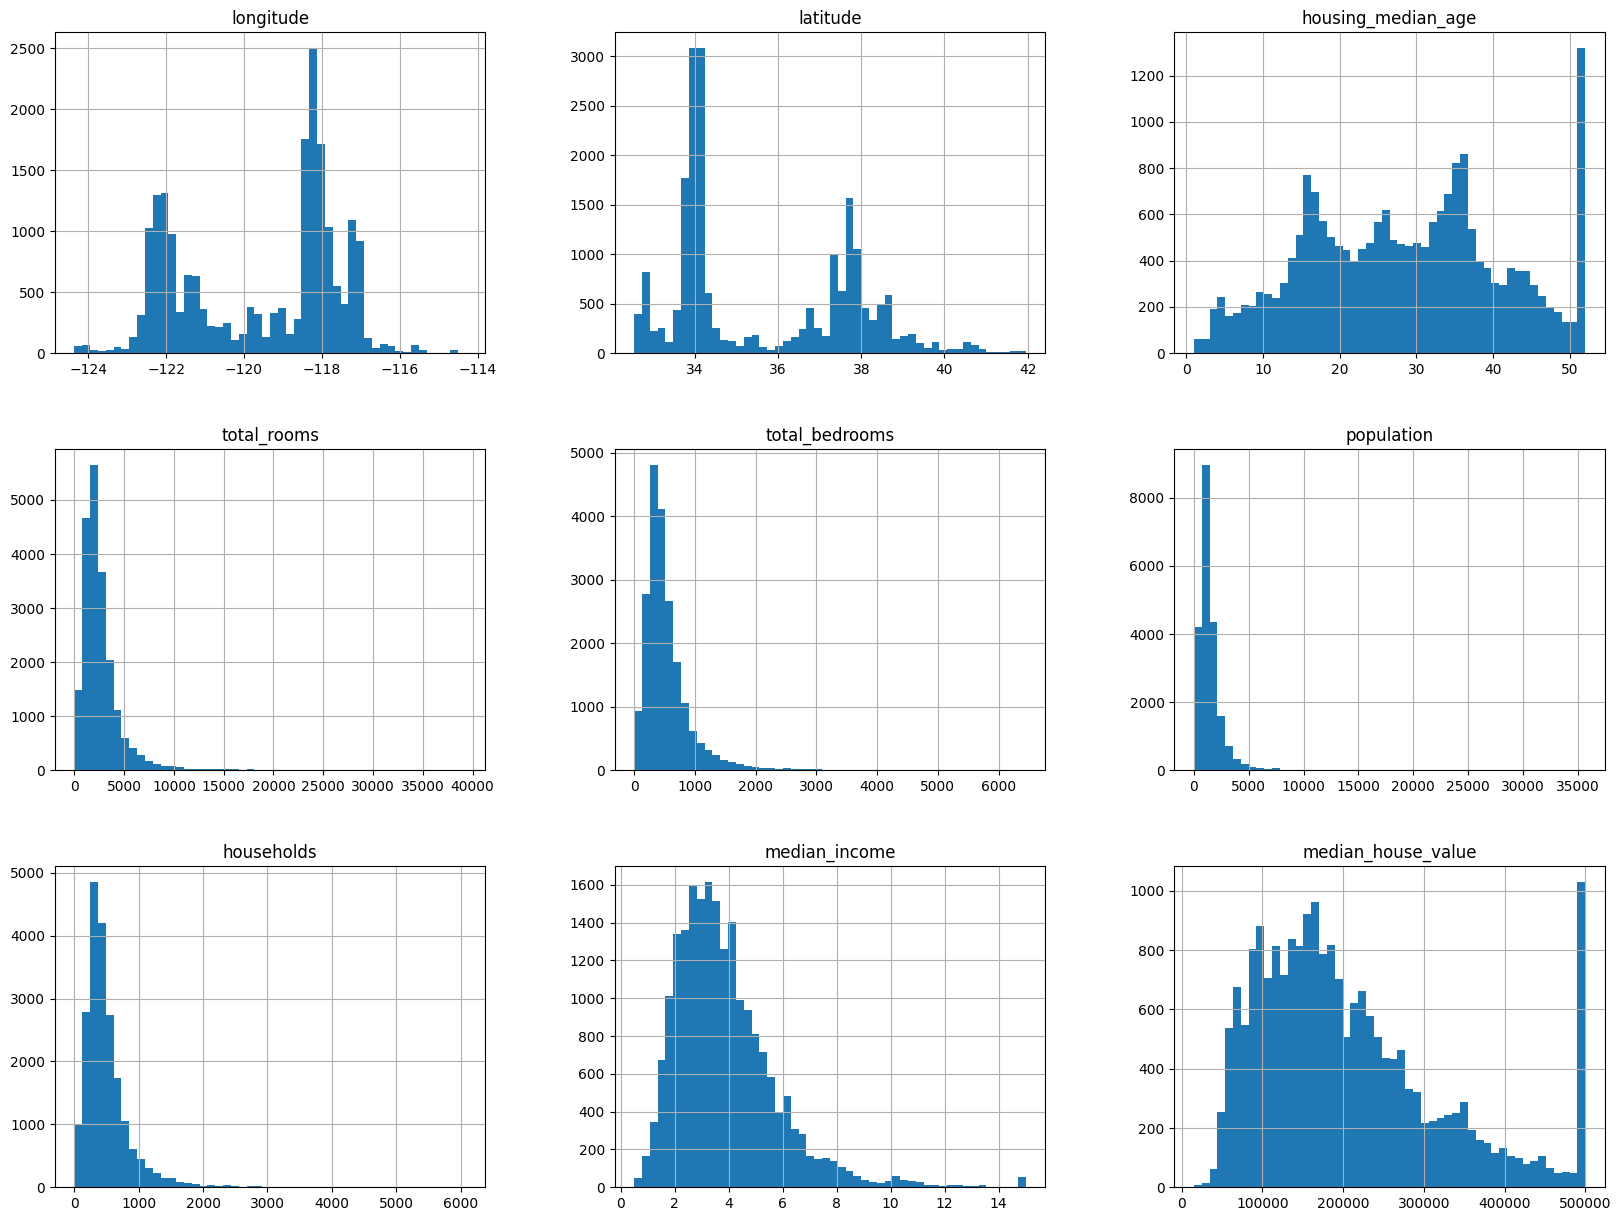

In [9]:
# Membuat histogram untuk semua fitur numerik dalam DataFrame

df.hist(bins=50, figsize=(20,15)) # bins=50: Menentukan jumlah 'kotak' (bins) pada histogram
                                  # figsize=(20,15): Mengatur ukuran keseluruhan figure plot
# Menampilkan plot histogram
plt.show()

Hasil analisis univariate menunjukkan distribusi dari sembilan variabel numerik. Beberapa insight yang menjadi temuan utama sebagai berikut:
  - **longitude & latitude**: Distribusi spasial menunjukkan konsentrasi data pada lokasi tertentu.
  - **housing_median_age**: Banyak rumah memiliki usia maksimum (50 tahun). Distribusinya relatif merata namun menunjukkan puncak signifikan pada batas usia tertinggi.
  - **total_rooms, total_bedrooms, population, households**: Semua variabel ini menunjukkan distribusi miring ke kanan (*right-skewed*), dengan sebagian besar nilai berada di kisaran rendah, namun terdapat nilai-nilai ekstrem yang besar. Hal ini mengindikasikan adanya potensi outlier.
  - **median_income**: Distribusi relatif normal, namun tetap menunjukkan sedikit kemiringan ke kanan. Pendapatan mayoritas rumah tangga berada di kisaran 2 hingga 5 satuan pendapatan median.
  - **median_house_value**: Terlihat adanya batas maksimum pada harga rumah (500,000). Distribusi miring ke kanan dan tidak simetris.

Temuan ini akan dipertimbangkan pada tahap transformasi data agar model lebih optimal

## **Multivariate Analysis**

#### **Categorical Features**

<ipython-input-10-7028da267a37>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=col, y='median_house_value', kind='bar', dodge=False, height = 4, aspect = 3, data = df, palette='Set3')


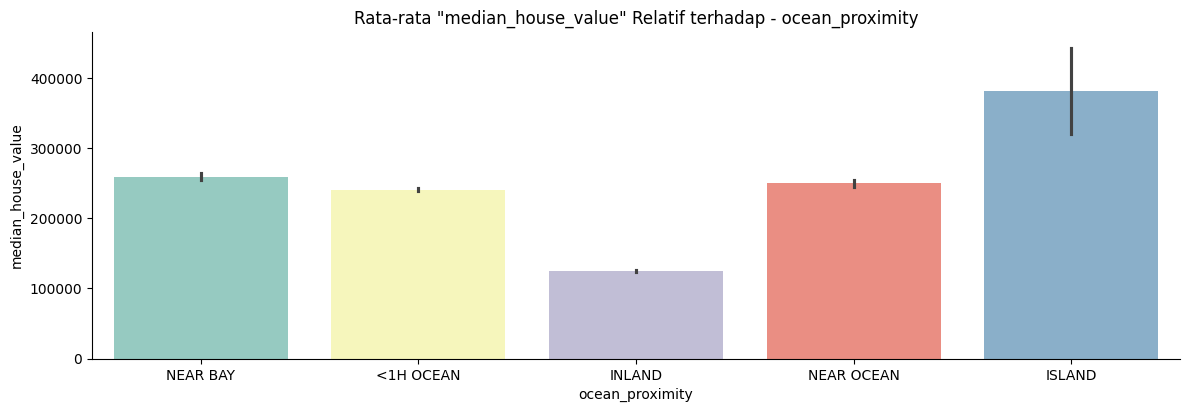

In [10]:
# Mengambil daftar nama kolom dengan tipe data 'object' (fitur kategorikal)
cat_features = df.select_dtypes(include='object').columns.to_list()

# Melakukan iterasi (looping) pada setiap fitur kategorikal
for col in cat_features:
  # Membuat plot kategori (catplot) untuk melihat hubungan fitur kategorikal dengan 'median_house_value'
  sns.catplot(x=col, y='median_house_value', kind='bar', dodge=False, height = 4, aspect = 3, data = df, palette='Set3')
  plt.title('Rata-rata "median_house_value" Relatif terhadap - {}'.format(col)) # Menambahkan judul pada plot untuk menjelaskan hubungan yang ditampilkan

`ocean_proximity` memiliki pengaruh signifikan terhadap harga median rumah (`median_house_value`). Properti yang sangat dekat dengan laut (`NEAR OCEAN` dan `<1H OCEAN`) cenderung memiliki harga median yang lebih tinggi dibandingkan dengan lokasi yang jauh dari laut (`INLAND`). Kategori `ISLAND`, meskipun jarang, menunjukkan harga median yang paling tinggi, menegaskan nilai premium lokasi pulau.

#### **Numerical Features**

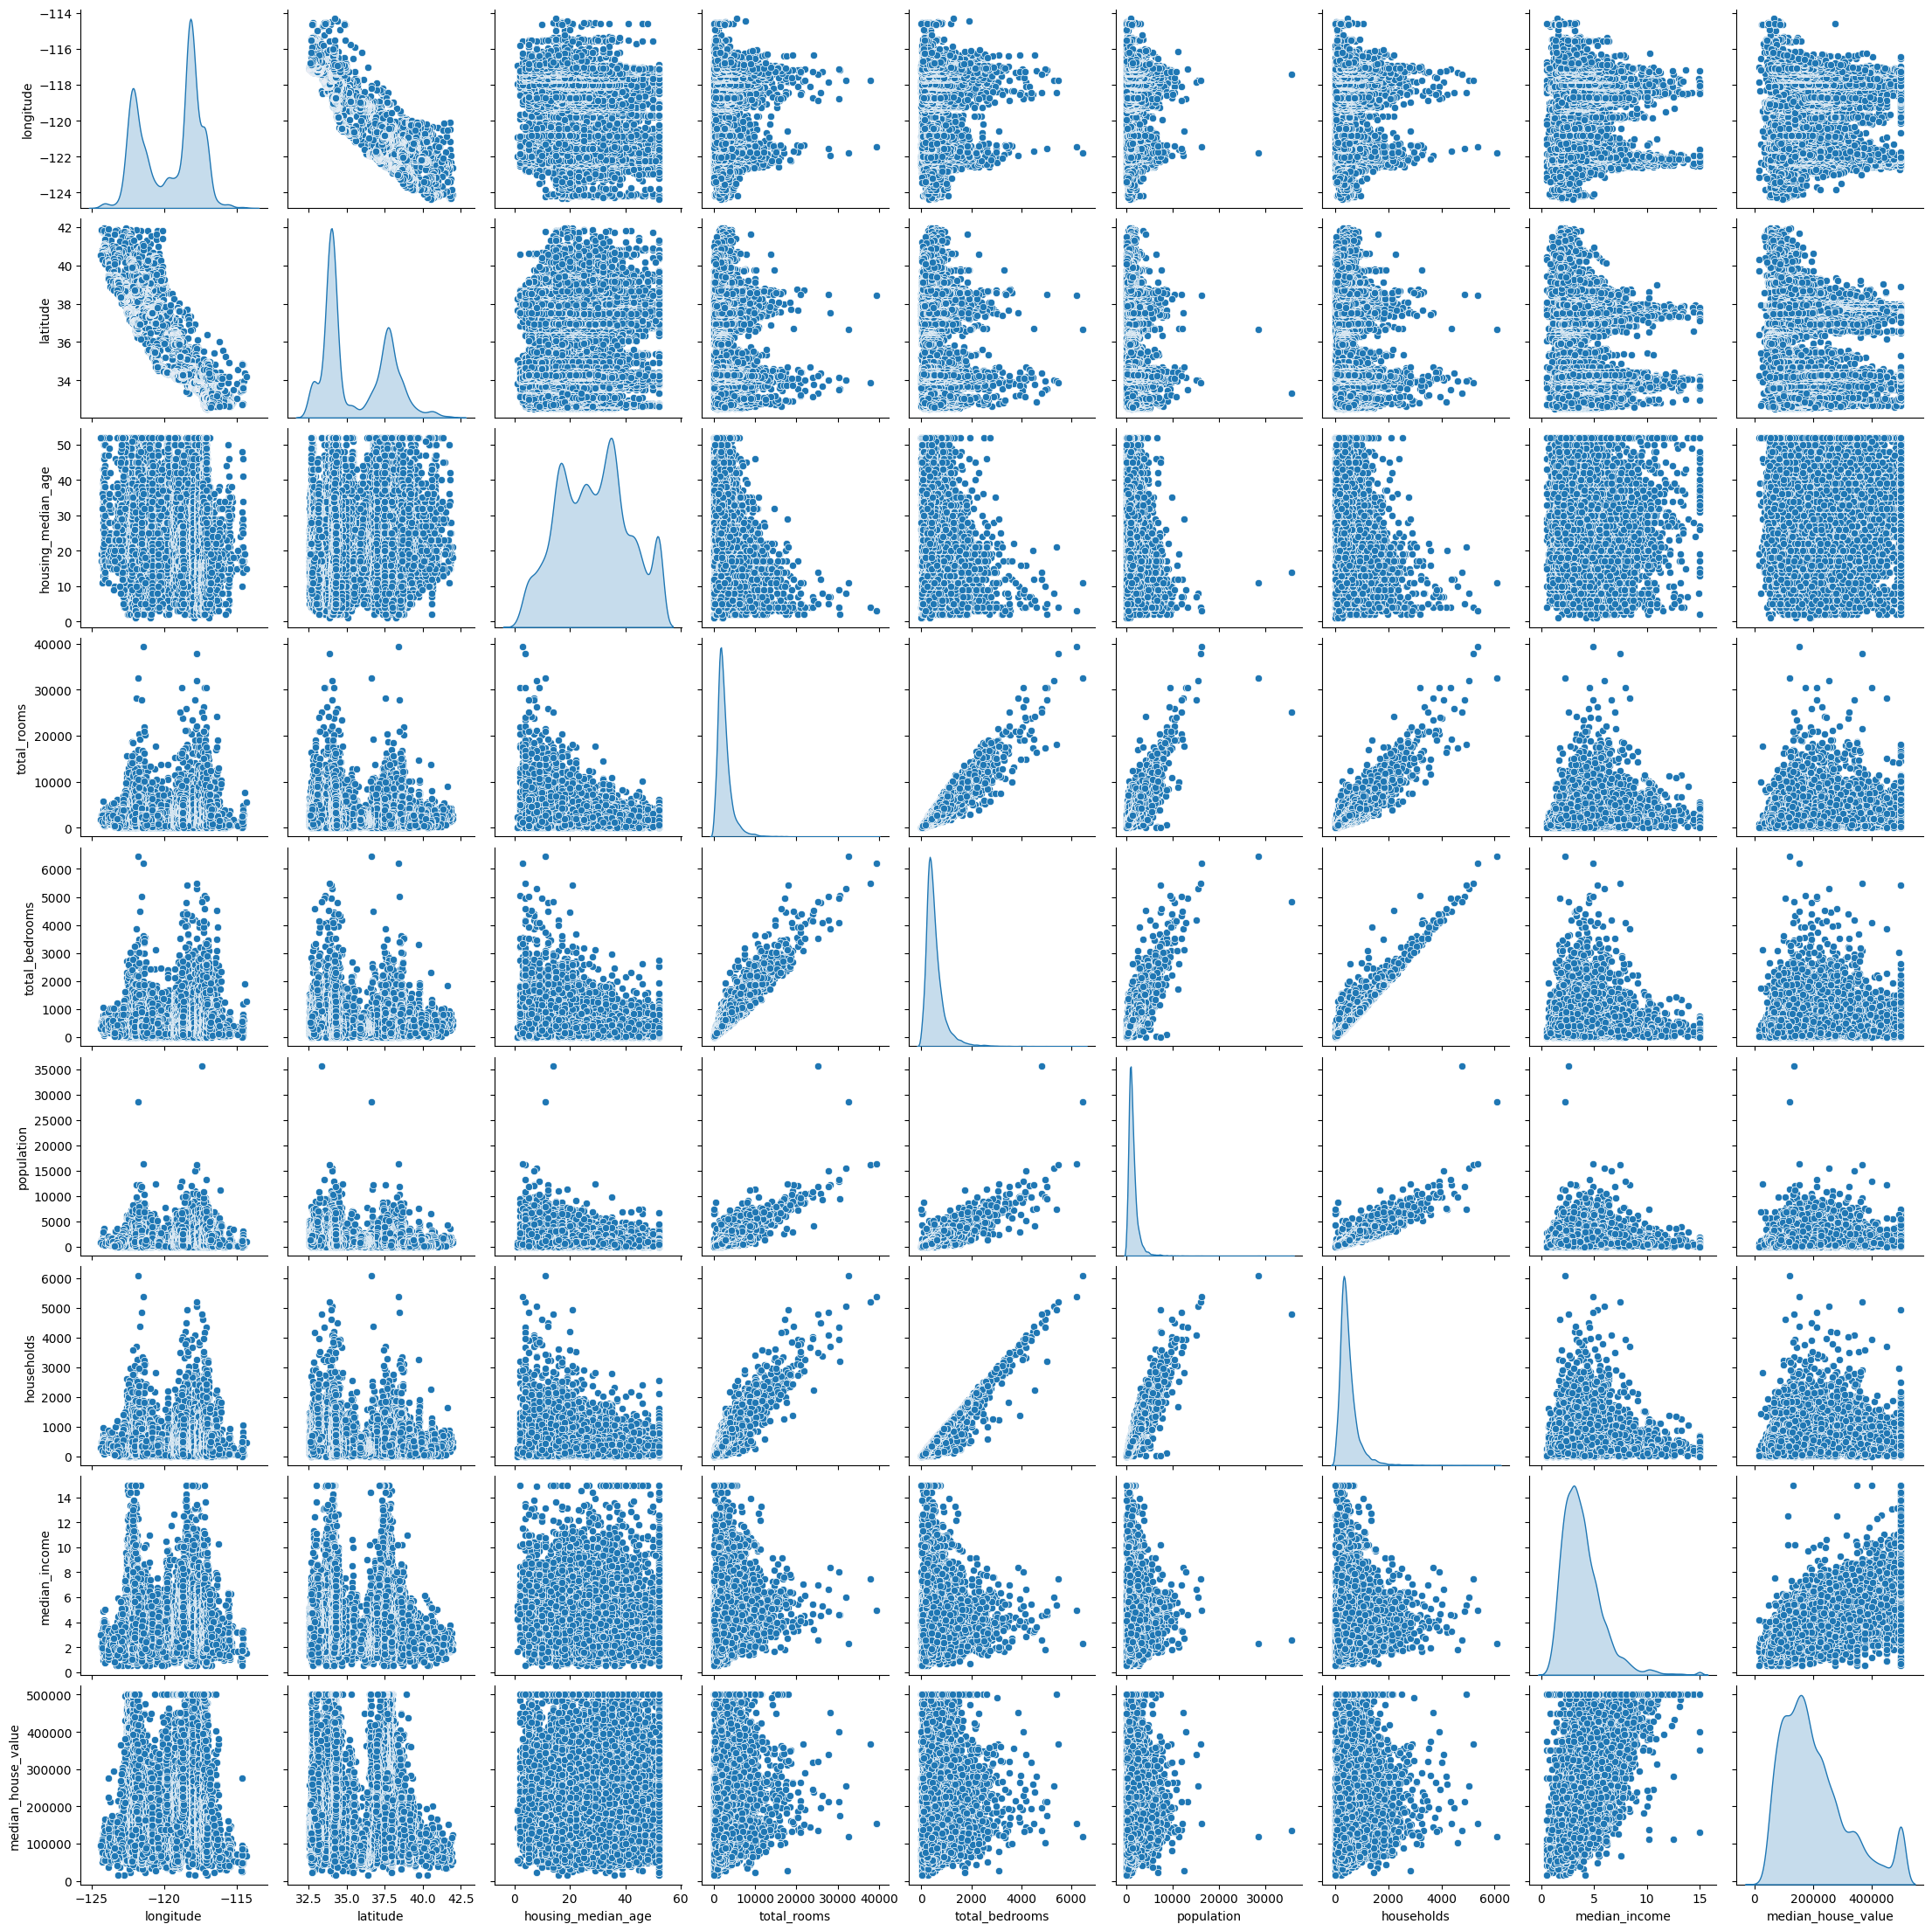

In [11]:
# Memvisualisasikan relasi antara fitur numerik dengan menggunakan fungsi pairplot
sns.pairplot(df, diag_kind='kde')

Text(0.5, 1.0, 'Correlation Matrix untuk Fitur Numerik ')

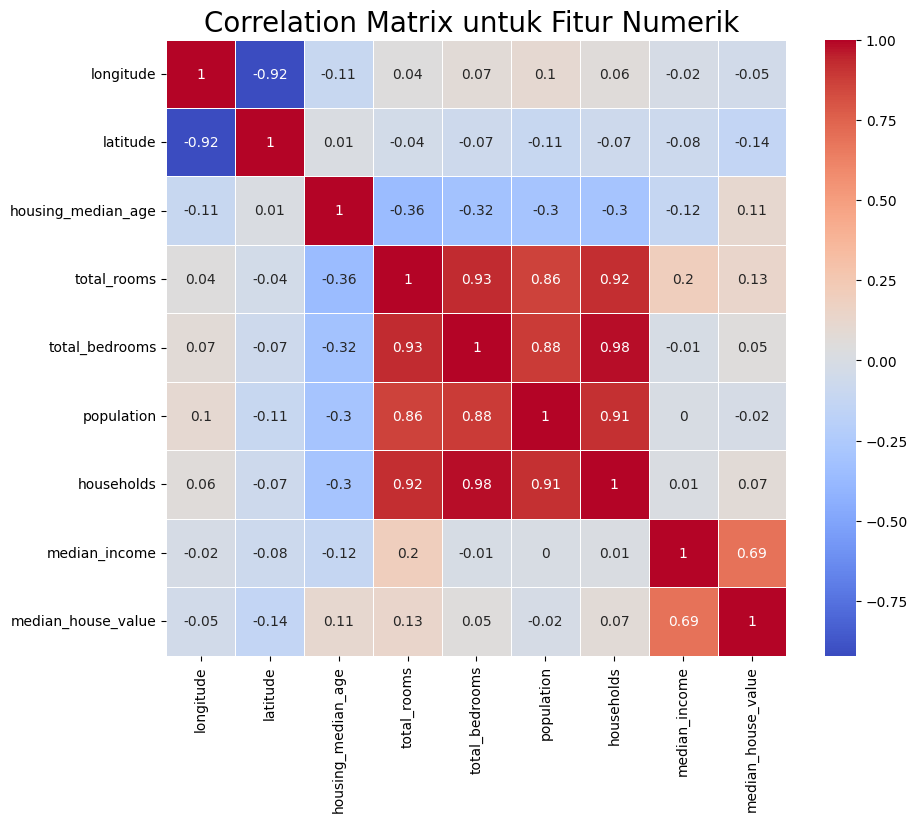

In [12]:
# Memvisualisasikan skor korelasi antar fitur numerik dengan fungsi corr()
plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_features].corr().round(2)

# Menampilkan nilai di dalam box korelasi, dengan annot=True
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix untuk Fitur Numerik ", size=20)

Multivariate Analysis mengungkap bahwa pendapatan median (`median_income`) berkorelasi positif paling kuat dengan harga rumah (`median_house_value`). Lokasi geografis (`longitude`, `latitude`) menunjukkan korelasi negatif, sementara fitur ukuran properti berkorelasi lemah dengan harga namun kuat antar sesamanya.

# **Data Preprocessing**

## **Handling Missing Values**

In [13]:
# Menghapus (drop) baris yang mengandung nilai yang hilang (NaN) dari DataFrame
df.dropna(inplace=True)

In [14]:
# Menampilkan informasi jumlah nilai yang hilang (missing values) setelah di hapus (drop)
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [15]:
# Menampilkan lima baris pertama DataFrame
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Terdapat 207 baris yang kosong untuk kolom `total_bedrooms`. Mengingat proporsinya yang relatif kecil terhadap keseluruhan dataset, pendekatan penghapusan baris (row deletion) diaplikasikan. Cara ini dipilih agar datanya tetap bersih dan lengkap tanpa perlu mengisi bagian yang kosong dengan perkiraan atau nilai buatan.

## **Handling Outliers**

### **Boxplot Visualization**

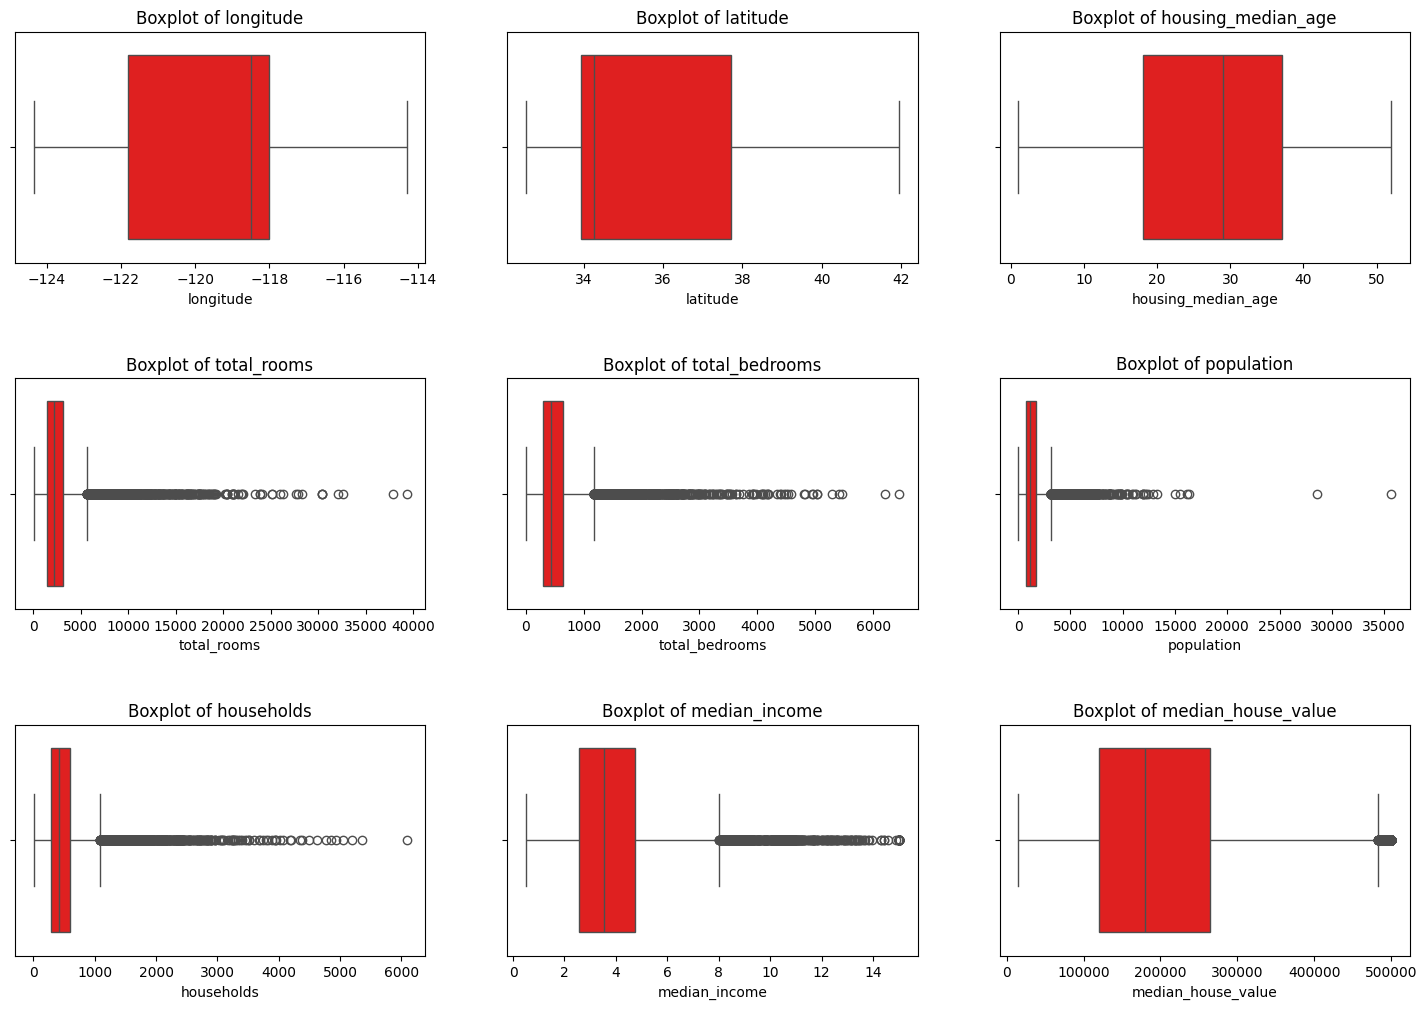

In [16]:
# Membuat visualisasi boxplot untuk setiap numerical_features
plt.figure(1 , figsize = (18 , 12)) # Membuat plot figure kosong
n = 0 # Menginisialisasi counter untuk subplot
for x in numerical_features: # Melakukan Iterasi membuat boxplot untuk fitur numerik
    n += 1
    plt.subplot(3 , 3 , n)
    plt.subplots_adjust(hspace =0.5 , wspace = 0.2)
    sns.boxplot(x=df[x] , color='red') # Mengambil index fitur numerik untuk divisualisasikan menjadi boxplot
    plt.title('Boxplot of {}'.format(x)) # Memberi judul boxplot untuk setiap fiturnya
plt.show()

Visualisasi mengungkapkan keberadaan outlier pada beberapa fitur numerik, terutama pada variabel yang terkait dengan ukuran properti (`total_rooms`,` total_bedrooms`, `population`, `households`) serta `median_income` dan `median_house_value`. Boxplot ini secara visual menyoroti adanya nilai-nilai data yang berada jauh di luar rentang nilai umum, mengindikasikan potensi keberadaan anomali atau nilai ekstrem yang perlu ditangani untuk mencegah dampak negatif pada performa model prediktif.

### **IQR Method**

In [17]:
# Mendefinisikan variabel numerical_cols
numerical_cols = df.select_dtypes(include='number').columns

# Menghitung Q1, Q3 dan IQR untuk variabel numerical_cols
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Membuat filter pada numerical_cols untuk menghapus (drop) kolom dengan outlier
filter_outliers = ~((df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

# Mengimplementasikan filter pada dataset (termasuk kolom non-numerical)
df = df[filter_outliers]

# Mengecek shape dataset setelah menghapus (drop) outliers shape after dropping outliers
df.shape

(17434, 10)

Metode Interquartile Range (IQR) digunakan untuk mengidentifikasi dan menghapus baris yang mengandung outlier pada fitur-fitur numerik yang telah terdeteksi melalui visualisasi boxplot. Dengan menerapkan ambang batas 1.5 kali IQR dari kuartil pertama (Q1) dan ketiga (Q3), observasi yang nilai numeriknya berada di luar rentang tersebut dianggap sebagai outlier dan dihapus dari dataset. Prosedur ini bertujuan untuk membersihkan data dari nilai ekstrem yang berpotensi mengganggu kinerja model, menghasilkan dataset dengan jumlah baris yang berkurang setelah proses ini.

## **Encoding Categorical Features**

### **OneHotEncoding**

In [18]:
# Melakukan One-Hot Encoding pada fitur kategorikal 'ocean_proximity'
df = pd.concat([df, pd.get_dummies(df['ocean_proximity'], prefix='ocean_proximity')],axis=1)
df.drop(['ocean_proximity'], axis=1, inplace=True)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,False,False,False,True,False
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,False,False,False,True,False


Fitur kategorikal `ocean_proximity` diubah menjadi format numerik menggunakan metode One-Hot Encoding. Proses ini menciptakan kolom-kolom biner baru untuk setiap kategori unik dalam fitur asli, memungkinkan algoritma model yang berbasis matematika untuk memproses informasi kategorikal tersebut. Hal ini merupakan langkah krusial untuk menyiapkan data non-numerik agar kompatibel dengan sebagian besar model machine learning.

## **Dimensionality Reduction using PCA**

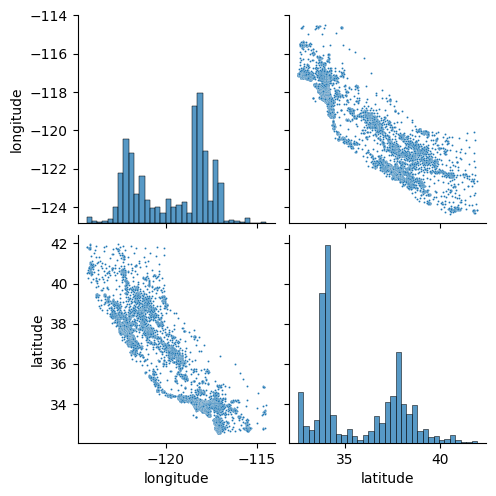

In [19]:
# Memvisualisasikan relasi antara fitur 'longitude' dan 'latitude' menggunakan pairplot
sns.pairplot(df[['longitude','latitude']], plot_kws={"s": 2});

In [20]:
# Mengimplementasikan Principal Component Analysis (PCA)
pca = PCA(n_components=1, random_state=123) # n_components=1: Menentukan jumlah komponen utama yang ingin dipertahankan

# Melatih objek PCA menggunakan fitur 'longitude' dan 'latitude' dari DataFrame
pca.fit(df[['longitude','latitude']])

# Mentransformasi fitur 'longitude' dan 'latitude' menggunakan PCA yang sudah dilatih
df['coordinate'] = pca.transform(df.loc[:, ('longitude','latitude')]).flatten()

# Menghapus kolom 'longitude' dan 'latitude' asli dari DataFrame
df.drop(['longitude','latitude'], axis=1, inplace=True)

In [21]:
# Menampilkan proporsi komponen utama setelah PCA
pca.explained_variance_ratio_.round(3)

array([0.962])

In [22]:
# Menampilkan lima baris pertama DataFrame setelah dilakukan reduksi dimensi dengan PCA
df.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,coordinate
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False,3.367134
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False,3.373902
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False,3.373902
5,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,False,False,False,True,False,3.373902
6,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,False,False,False,True,False,3.366539


Untuk menyederhanakan representasi spasial, fitur `longitude` dan `latitude` direduksi dimensinya menjadi satu fitur gabungan tunggal bernama `coordinate` menggunakan Principal Component Analysis (PCA). Langkah ini bertujuan menangkap variasi utama dari kedua fitur geografis tersebut dalam satu variabel, menyederhanakan input model sambil tetap mempertahankan informasi lokasi yang penting.

## **Data Splitting**

In [23]:
# Memisahkan fitur (variabel independen) dan target (variabel dependen)
X = df.drop(["median_house_value"],axis =1) # DataFrame fitur
y = df["median_house_value"] # Series target

# Membagi dataset menjadi data training dan data testing dengan proporsi data testing sebesar 10% (data training akan menjadi 90%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 123)

In [24]:
# Menampilkan jumlah total sampel (baris) dalam keseluruhan dataset sebelum dibagi
print(f'Total # of sample in whole dataset: {len(X)}')

# Menampilkan jumlah total sampel (baris) dalam data training setelah dibagi
print(f'Total # of sample in train dataset: {len(X_train)}')

# Menampilkan jumlah total sampel (baris) dalam data testing setelah dibagi
print(f'Total # of sample in test dataset: {len(X_test)}')

Total # of sample in whole dataset: 17434
Total # of sample in train dataset: 15690
Total # of sample in test dataset: 1744


Tahap pembagian data memisahkan dataset menjadi dua subset: data training (90%) dan data testing (10%). Proses ini dilakukan menggunakan `train_test_split` dengan `random_state` tertentu untuk memastikan hasil yang dapat direproduksi. Pembagian ini krusial agar model dilatih hanya pada data training dan kemudian dievaluasi performanya secara objektif pada data testing yang belum pernah dilihat sebelumnya, memberikan estimasi kinerja model di dunia nyata.

## **Standardization**

In [25]:
# Mendefinisikan daftar nama fitur numerik yang akan di-standardisasi
numerical_features = numerical_features = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'coordinate']

# Mendefinisikan fungsi scaler dengan StandardScaler
scaler = StandardScaler()

# Menerapkan (fit) objek scaler hanya pada fitur numerik dari data training
scaler.fit(X_train[numerical_features])

# Mentransformasi (transform) fitur numerik pada data training menggunakan rata-rata dan standar deviasi yang sudah dihitung
X_train[numerical_features] = scaler.transform(X_train.loc[:, numerical_features])

# Menampilkan lima baris pertama fitur numerik di X_train setelah standardisasi untuk verifikasi
X_train[numerical_features].head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,coordinate
9980,-0.614686,-1.501992,-1.545449,-1.757920,-1.671622,-0.952736,1.352955
627,0.447466,0.385892,0.489782,0.334986,0.526329,-0.125958,1.112820
8706,0.365762,-0.350686,-0.525577,-0.384814,-0.426765,1.266262,-0.770439
6760,0.365762,0.713260,0.494295,0.396493,0.735426,0.458963,-0.753189
2662,0.284058,0.774872,0.656752,0.040749,0.336683,-1.029612,2.112382


In [26]:
# Menampilkan statistik deskriptif (mean, std, min, max, kuartil) untuk fitur numerik di X_train
X_train[numerical_features].describe().round(4)

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,coordinate
count,15690.0000,15690.0000,15690.0000,15690.0000,15690.0000,15690.0000,15690.0000
mean,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-2.3305,-1.9682,-2.0012,-1.9840,-2.0169,-2.1298,-1.9192
25%,-0.8598,-0.7038,-0.7151,-0.7156,-0.7088,-0.7530,-0.8138
50%,0.0389,-0.1539,-0.1555,-0.1371,-0.1447,-0.1287,-0.5650
75%,0.6926,0.5799,0.5981,0.6005,0.5993,0.6347,1.0619
max,1.8364,3.2485,3.2831,3.2042,3.2738,3.0771,2.6530


Tahap Standardization menyeragamkan skala fitur-fitur numerik menggunakan `StandardScaler`. Proses ini mentransformasi data sedemikian rupa sehingga setiap fitur memiliki rata-rata nol dan standar deviasi satu. Penerapan scaler ini hanya dilatih pada data training dan kemudian diterapkan pada data testing untuk mencegah data leakage, memastikan bahwa model tidak mendapatkan informasi tentang distribusi data testing sebelum evaluasi. Standardization penting agar fitur dengan skala berbeda tidak mendominasi dalam proses pelatihan model, khususnya pada algoritma yang sensitif terhadap skala.

# **Model Development**

In [27]:
# Menyimpan DataFrame untuk Membandingkan Performa Model
models = pd.DataFrame(index=['train_mse', 'test_mse'],
                      columns=['KNN', 'RandomForest', 'AdaBoosting', 'SVR'])

## **K-Nearest Neighborhood (KNN)**

In [28]:
# Mengimplementasikan model Regresi K-Nearest Neighbors (KNN)
knn = KNeighborsRegressor(n_neighbors=10) # n_neighbors=10: Menentukan jumlah tetangga terdekat yang akan digunakan untuk prediksi

# Melatih model KNN menggunakan data training
knn.fit(X_train, y_train)

# Menghitung Mean Squared Error (MSE) pada data training untuk model KNN
# models.loc['train_mse','knn'] = ...: Menyimpan nilai MSE training ke dalam DataFrame 'models' pada baris 'train_mse' dan kolom 'knn'
models.loc['train_mse','knn'] = mean_squared_error(y_pred = knn.predict(X_train), y_true=y_train)

## **RandomForestRegressor**

In [29]:
# Mengimplementasikan model Regresi RandomForest (RF)
RF = RandomForestRegressor(n_estimators=150,    # Jumlah pohon dalam forest
                           max_depth=10,        # Kedalaman maksimum setiap pohon
                           min_samples_split=2, # Jumlah sampel minimum yang diperlukan untuk memecah node internal
                           min_samples_leaf=2,  # Jumlah sampel minimum yang diperlukan di node daun
                           max_features=0.5,    # Proporsi fitur yang dipertimbangkan saat mencari pemecahan terbaik (50%)
                           random_state=55,     # Seed untuk random number generator (untuk hasil yang dapat direproduksi)
                           n_jobs=-1)           # Menggunakan semua core processor yang tersedia untuk pelatihan (mempercepat proses)

# Melatih model RandomForest menggunakan data training
RF.fit(X_train, y_train)

# Menghitung Mean Squared Error (MSE) pada data training untuk model RandomForest
# models.loc['train_mse','RandomForest'] = ...: Menyimpan nilai MSE training ke dalam DataFrame 'models' pada baris 'train_mse' dan kolom 'RandomForest'
models.loc['train_mse', 'RandomForest'] = mean_squared_error(y_pred=RF.predict(X_train), y_true=y_train)

## **AdaBoostingRegressor**

In [30]:
# Mengimplementasikan model AdaBoostRegressor
adaboosting = AdaBoostRegressor(learning_rate=0.1, # Mengatur kontribusi setiap regressor (pohon) pada prediksi akhir
                                random_state=55)   # Mengatur seed untuk random number generator

# Melatih model AdaBoostRegressor menggunakan data training
adaboosting.fit(X_train, y_train)

# Menghitung Mean Squared Error (MSE) pada data training untuk model AdaBoostRegressor
# models.loc['train_mse','AdaBoosting'] = ...: Menyimpan nilai MSE training ke dalam DataFrame 'models' pada baris 'train_mse' dan kolom 'AdaBoosting'
models.loc['train_mse', 'AdaBoosting'] = mean_squared_error(y_pred=adaboosting.predict(X_train), y_true=y_train)

## **Suport Vector Regression**

In [31]:
# Mengimplementasikan model Regresi Suport Vector Regression
SVR = SVR(degree=5,    # Menentukan derajat fungsi polinomial yang akan digunakan untuk mentransformasi data (diabaikan jika kernel bukan 'poly')
          epsilon=0.5) # Menentukan lebar "epsilon-tube" di sekitar garis regresi yang diprediksi (kesalahan dalam jarak ini tidak dikenakan penalti)

# Melatih model Suport Vector Regression menggunakan data training
SVR.fit(X_train, y_train)

# Menghitung Mean Squared Error (MSE) pada data training untuk model Suport Vector Regression
# models.loc['train_mse','SVR'] = ...: Menyimpan nilai MSE training ke dalam DataFrame 'models' pada baris 'train_mse' dan kolom 'SVR'
models.loc['train_mse', 'SVR'] = mean_squared_error(y_pred=SVR.predict(X_train), y_true=y_train)

Tahap pengembangan model melibatkan pembangunan empat model regresi prediktif: `K-Nearest Neighborhood` (KNN), `RandomForest Regressor`, `AdaBoost Regressor` (AdaBoosting), dan `Support Vector Regression` (SVR). Masing-masing model dilatih menggunakan data training yang telah melalui tahapan preprocessing dan preparation. Setelah proses pelatihan, `Mean Squared Error` (MSE) dihitung pada data training untuk setiap model, menjadi indikator awal performa model pada data yang digunakan untuk pelatihan.

# **Model Evaluation**

In [32]:
# Melakukan standardisasi (scaling) pada fitur numerik di data testing (X_test)
X_test.loc[:, numerical_features] = scaler.transform(X_test[numerical_features])

In [33]:
# Membuat DataFrame kosong untuk menyimpan nilai MSE (Mean Squared Error) training dan testing
mse = pd.DataFrame(columns=['train', 'test'], index=['KNN', 'RF', 'AdaBoosting', 'SVR'])

# Membuat dictionary yang berisi objek model regresi yang sudah dilatih
# key dictionary adalah nama model (string), value-nya adalah objek model itu sendiri
model_dict = {'KNN': knn, 'RF': RF, 'AdaBoosting': adaboosting, 'SVR': SVR}

# Melakukan iterasi (looping) pada setiap model dalam dictionary 'model_dict'
for name, model in model_dict.items():
    # Menghitung Mean Squared Error (MSE) pada data training
    # mse.loc[name, 'train'] = ...: Menyimpan nilai MSE training ke DataFrame 'mse' pada baris 'name' dan kolom 'train'
    mse.loc[name, 'train'] = mean_squared_error(y_true=y_train, y_pred=model.predict(X_train))/1e3 # /1e3: Membagi hasil MSE dengan 1000

    # Menghitung Mean Squared Error (MSE) pada data testing
    # mse.loc[name, 'test'] = ...: Menyimpan nilai MSE testing ke DataFrame 'mse' pada baris 'name' dan kolom 'test'
    mse.loc[name, 'test'] = mean_squared_error(y_true=y_test, y_pred=model.predict(X_test))/1e3 # /1e3: Membagi hasil MSE dengan 1000

# Menampilkan DataFrame 'mse' yang berisi hasil MSE training dan testing untuk setiap model
mse

,train,test
KNN,2313994.530776,2721791.745701
RF,1747114.417286,2363565.449537
AdaBoosting,4167215.125633,3982864.983359
SVR,9035975.230688,8697667.120081


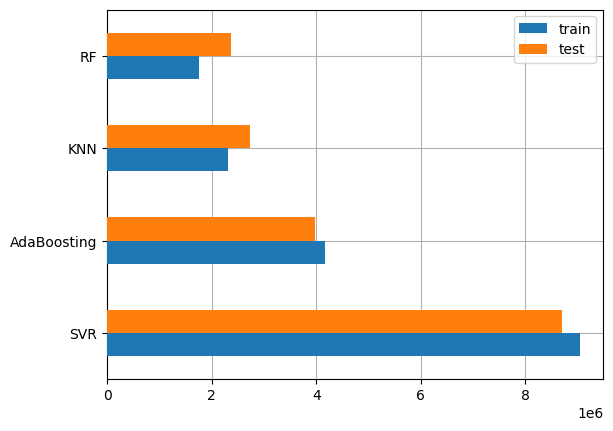

In [34]:
# Membuat figure dan axes untuk visualisasi plot hasil evaluasi model
fig, ax = plt.subplots()

# Mengurutkan DataFrame berdasarkan kolom 'test' (MSE testing) secara descending
mse.sort_values(by='test', ascending=False).plot(kind='barh', ax=ax, zorder=3) # Memplot hasil MSE testing secara horizontal (barh)

# Menambahkan grid (garis bantu) pada axes; zorder=0 menempatkan grid di belakang batang plot
ax.grid(zorder=0)

Tahap evaluasi model membandingkan performa keempat model regresi (`KNN`, `RandomForest`, `AdaBoosting`, `SVR`) berdasarkan metrik `Mean Squared Error` (MSE) pada data training dan data testing. Berdasarkan nilai `MSE` pada data testing, model `RandomForest` adalah model yang paling unggul dalam memprediksi harga rumah pada dataset ini, diikuti oleh model `KNN`. Model `AdaBoosting` dan `SVR` menunjukkan performa yang kurang memuaskan dibandingkan kedua model tersebut. Pemilihan model terbaik untuk tugas prediksi harga rumah ini jatuh pada `RandomForest` berkat nilai `MSE` testing-nya yang paling rendah.

# **Feature Importance**

In [35]:
# Fit model Random Forest sebagai model dengan performa terbaik
# Menginisialisasi dan melatih model Random Forest Regressor, dengan random_state untuk konsistensi
model = RandomForestRegressor(random_state=55)
model.fit(X, y)

# Mengekstrak skor kepentingan setiap fitur dari model Random Forest yang telah dilatih
importances = model.feature_importances_
features = X.columns # Mengambil nama kolom (fitur) dari DataFrame X

# Membuat DataFrame pandas untuk menyajikan hasil feature importance secara terstruktur
feat_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False) # Mengurutkan DataFrame berdasarkan kolom 'Importance' dari yang terbesar ke terkecil

# Menampilkan DataFrame yang berisi daftar fitur dan skor kepentingannya yang sudah diurutkan
print(feat_importance)

                       Feature  Importance
5                median_income    0.380533
7       ocean_proximity_INLAND    0.204061
11                  coordinate    0.176961
0           housing_median_age    0.061176
3                   population    0.051788
1                  total_rooms    0.039777
2               total_bedrooms    0.035693
4                   households    0.032941
10  ocean_proximity_NEAR OCEAN    0.009450
6    ocean_proximity_<1H OCEAN    0.004906
9     ocean_proximity_NEAR BAY    0.001744
8       ocean_proximity_ISLAND    0.000970


Fitur yang paling berpengaruh dalam memprediksi harga rumah `median_house_value` adalah `median_income`. Ini menunjukkan bahwa pendapatan median rumah tangga di suatu area merupakan faktor kunci dalam menentukan nilai properti di California. Fitur lainnya seperti koordinat geografis `coordinate` dan usia rumah `housing_median_age` juga memiliki kontribusi yang signifikan, tetapi tidak sebesar pendapatan.

# **Demonstrasi Prediksi pada Data Tunggal**

In [36]:
# Memilih satu baris pertama dari data testing (X_test) sebagai data input untuk inferensi
predict = X_test.iloc[:1].copy() # .copy(): Membuat salinan data untuk menghindari peringatan SettingWithCopyWarning

# Membuat dictionary untuk menyimpan nilai aktual (y_true) dan nilai prediksi dari setiap model
pred_dict = {'y_true':y_test[:1]}

# Melakukan iterasi (looping) pada setiap model dalam dictionary 'model_dict'
for name, model in model_dict.items():
    # Membuat prediksi menggunakan model saat ini pada data input 'predict'
    pred_dict['Prediksi '+ name] = model.predict(predict).round(1)

# Mengubah dictionary 'pred_dict' menjadi DataFrame untuk tampilan yang lebih mudah dibaca
pd.DataFrame(pred_dict)

,y_true,Prediksi KNN,Prediksi RF,Prediksi AdaBoosting,Prediksi SVR
2757,75500.0,84200.0,73726.3,95191.9,169577.4


Pada satu sampel uji (nilai aktual 75500), model `RandomForest` memberikan prediksi terdekat (73726.3), diikuti `KNN` dan `AdaBoosting`. `SVR` menunjukkan prediksi yang paling jauh. Ini mendukung performa `RandomForest` sebagai model yang terbaik.